<a href="https://colab.research.google.com/github/aragaoian/dip-notebooks/blob/master/notebooks/seam_carving.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seam Carving

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [ ]:
a = np.array([2,7,9])
b = np.array([3,5,8])

print(np.convolve(a, b))

[  6  31  78 101  72]


## 1. Load image

(np.float64(-0.5), np.float64(1427.5), np.float64(967.5), np.float64(-0.5))

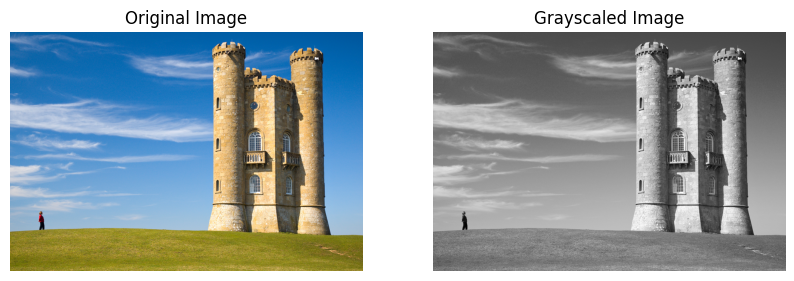

In [ ]:
img = cv2.imread("Broadway_tower_edit.jpg")

rgb_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
grayscale_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axs[0].imshow(rgb_image, vmin=0, vmax=255)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(grayscale_img, cmap="gray", vmin=0, vmax=255)
axs[1].set_title("Grayscaled Image")
axs[1].axis("off")

## 2. Calculate Pixel Intensity

### Convolution

In [ ]:
def add_padding(img, padding_height, padding_width):
    h, w = img.shape

    padded_img = np.zeros((h + padding_height * 2, w + padding_width * 2))
    padded_img[padding_height : h + padding_height, padding_width : w + padding_width] = img

    return padded_img

In [ ]:
def conv2d(img, kernel, padding=True, floatOut=False):
    k_height, k_width = kernel.shape
    img_height, img_width = img.shape

    pad_height = k_height // 2
    pad_width = k_width // 2

    # Create a padded version of the image to handle edges
    if padding:
        img = add_padding(img, pad_height, pad_width)

    output = np.zeros((img_height, img_width), dtype=float)

    # Perform convolution
    # Iterate only on original image
    for i in range(pad_height, img_height + pad_height):
        for j in range(pad_width, img_width + pad_width):
            accumulation = 0
            for u in range(k_height):
                for v in range(k_width):
                    # Accumulate pixel and neighboors, multiplying kernel entry
                    # with the corresponding pixel entry
                    accumulation += kernel[u, v] * img[i - pad_height + u, j - pad_width + v]
            output[i-pad_height,j-pad_width] = accumulation
    if(floatOut):
      return output
    else:
      return np.array(output, dtype=np.uint8)


In [ ]:
# Sobel X and Y
x_kernel = np.array([[-1, 0, 1],
                [-2, 0, 2],
                [-1, 0, 1]])
y_kernel = np.array([[-1, -2, -1],
                [ 0,  0,  0],
                [ 1,  2,  1]])

gx = conv2d(grayscale_img, x_kernel, padding=True, floatOut=True)
gy = conv2d(grayscale_img, y_kernel, padding=True, floatOut=True)

# Calculate gradient magnitude
magnitude = np.sqrt(gx**2 + gy**2)
sobel_gradient_magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)

### FFT - Fast Fourier Transform

### Results

(np.float64(-0.5), np.float64(1427.5), np.float64(967.5), np.float64(-0.5))

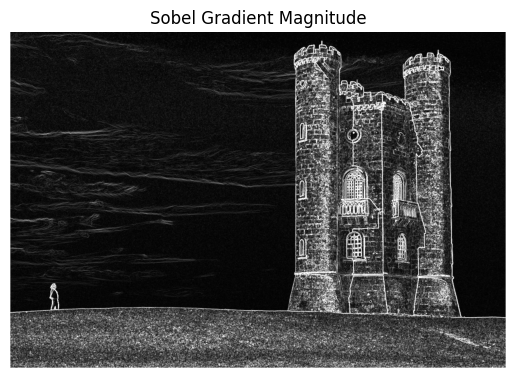

In [ ]:
plt.imshow(sobel_gradient_magnitude, cmap="gray", vmin=0, vmax=255)
plt.title("Sobel Gradient Magnitude")
plt.axis("off")

## 3. Seam Algorithm

In [63]:
a = np.array([
    [1,4,3,5,2],
    [3,2,5,2,3],
    [5,2,4,2,1]
])

def calc_minimal_energy(img, row, col):
    return min(img[
        row-1,
        (col if col-1 < 0 else col - 1): col+2
    ])

def cumulative_sum(img):
    m,n = img.shape
    cumulative_sum_matrix = np.zeros((m,n))
    cumulative_sum_matrix[0] = img[0]

    # calculate cumulative sum
    for row in range(1, m):
        for col in range(n):
            cumulative_sum_matrix[row,col] = img[row,col] + calc_minimal_energy(cumulative_sum_matrix,row,col)
    return cumulative_sum_matrix

def compute_seams(img):
    # compute seams, working back up the minimals to recover the seam
    m,n = img.shape
    seams = []
    for row in range(m-1, 1, -1):
        row_vals = img[row]                   # just the row
        minimal = np.min(row_vals)            # min value in that row
        cols = np.where(row_vals == minimal)[0]   # all column indices
        print(cols)




new_a = cumulative_sum(img=a)
compute_seams(img=new_a)


[1 4]
